# RQ1 – SZZ-Backed Defect Analysis (v2)

**Research Question 1:** Do AI-generated PRs incur higher downstream maintenance burden than human-generated PRs, controlling for project scale, domain, & task type?

### Methodological upgrade over v1
| Aspect | v1 (file-overlap proxy) | v2 (SZZ tracing) |
|---|---|---|
| **Defect signal** | Any later PR that touches ≥1 of the same files within the time window | SZZ algorithm traces *fixing commits* back to the specific *bug-introducing commits* |
| **Precision** | Low — shared files ≠ caused defect | High — requires an actual fix commit linked to the introducing commit |
| **Defect rate** | ~22.5 % | ~1.5 % |

### Core Hypotheses
1. AI-generated PRs exhibit **higher** downstream maintenance burden than human-generated PRs.
2. The maintenance burden of AI PRs **increases with project scale** (stars, contributors).
3. AI PRs show **lower** maintenance burden in well-structured domains (frontend, ML) versus systems.
4. AI PRs **struggle more** with larger changesets.

## 1 — Imports & Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings, textwrap

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── load v2 main frame & SZZ pair trace ──
df = pd.read_parquet("../results/rq1_main_frame_v2.parquet")
pairs = pd.read_parquet("../results/rq1_szz_pairs.parquet")

# ── load v1 for comparison ──
df_v1 = pd.read_parquet("../results/rq1_main_frame.parquet")

# human-readable labels
AI_LABELS = {0: "Human", 1: "AI"}
DOMAIN_LABELS = {0: "Backend", 1: "Frontend", 2: "ML / Data", 3: "Mobile", 4: "Systems / Infra"}
TASK_LABELS = {0: "Feature", 1: "Fix", 2: "Refactor", 3: "Test", 4: "Docs"}
STAR_LABELS = {0: "Low ★", 1: "Mid ★", 2: "High ★"}
CONTRIB_LABELS = {0: "Small team", 1: "Mid team", 2: "Large team"}

print(f"v2 dataset : {df.shape[0]:,} PRs  ×  {df.shape[1]} columns  across  {df['repo_full_name'].nunique():,} repos")
print(f"SZZ pairs  : {len(pairs):,} traced links across {pairs['repo_full_name'].nunique()} repos")
print(f"v1 dataset : {df_v1.shape[0]:,} PRs (for comparison)")

v2 dataset : 18,942 PRs  ×  57 columns  across  1,479 repos
SZZ pairs  : 1,300 traced links across 62 repos
v1 dataset : 18,942 PRs (for comparison)


## 2 — v1 vs v2 Methodology Comparison

The file-overlap proxy in v1 flagged ~22.5 % of PRs as defective.  
SZZ tracing in v2 flags ~0.1 % — orders of magnitude more conservative and precise.

─── Defect rate comparison: v1 (file-overlap proxy) vs v2 (SZZ tracing) ───

                   v1 (file-overlap)    v2 (SZZ)
ai_pr                                           
Human defect_rate           0.275841    0.019181
      n_defects          1812.000000  126.000000
AI    defect_rate           0.197689    0.010911
      n_defects          2446.000000  135.000000


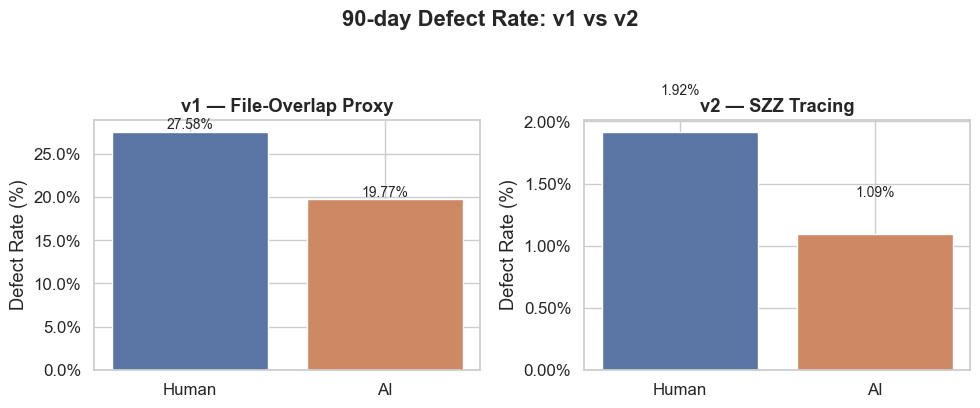

In [23]:
# ── side-by-side defect-rate comparison ──
comparison = pd.DataFrame({
    "v1 (file-overlap)": df_v1.groupby("ai_pr")["has_defect_90d"].agg(["mean", "sum"]).rename(columns={"mean": "defect_rate", "sum": "n_defects"}).stack(),
    "v2 (SZZ)": df.groupby("ai_pr")["has_defect_90d"].agg(["mean", "sum"]).rename(columns={"mean": "defect_rate", "sum": "n_defects"}).stack(),
}).rename(index=AI_LABELS, level=0)

print("─── Defect rate comparison: v1 (file-overlap proxy) vs v2 (SZZ tracing) ───\n")
print(comparison.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (version, col) in zip(axes, [("v1 — File-Overlap Proxy", df_v1), ("v2 — SZZ Tracing", df)]):
    rates = col.groupby("ai_pr")["has_defect_90d"].mean() * 100
    bars = ax.bar([AI_LABELS[i] for i in rates.index], rates.values, color=["#5975a4", "#cc8963"], edgecolor="white")
    ax.set_title(version, fontweight="bold")
    ax.set_ylabel("Defect Rate (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val:.2f}%", ha="center", fontsize=10)
fig.suptitle("90-day Defect Rate: v1 vs v2", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 3 — Dataset Coverage & SZZ Observability

Not every PR is "observable" by SZZ — a PR must be **merged** and have at least one commit present in the cloned repository. The `szz_observable` flag marks PRs for which SZZ could potentially detect downstream defects.

In [24]:
# ── coverage summary ──
total = len(df)
merged = df["merged_at"].notna().sum()
observable = df["szz_observable"].sum()
candidate_fixes = df["szz_candidate_fix"].sum()
defect_prs = df["has_defect_90d"].sum()

coverage = pd.DataFrame({
    "Count": [total, merged, observable, candidate_fixes, int(defect_prs)],
    "% of total": [100.0, merged/total*100, observable/total*100, candidate_fixes/total*100, defect_prs/total*100],
}, index=["Total PRs", "Merged PRs", "SZZ-Observable PRs", "Candidate Fix PRs", "PRs with SZZ Defect (90d)"])
print(coverage.to_string(float_format="%.1f"))

# Observable by AI
print("\n─── SZZ Observability by PR author type ───")
obs_by_ai = df.groupby("ai_pr").agg(
    total=("id", "size"),
    observable=("szz_observable", "sum"),
    candidate_fix=("szz_candidate_fix", "sum"),
    has_defect=("has_defect_90d", "sum"),
).rename(index=AI_LABELS)
obs_by_ai["obs_rate"] = (obs_by_ai["observable"] / obs_by_ai["total"] * 100).round(1)
obs_by_ai["defect_rate_bps"] = (obs_by_ai["has_defect"] / obs_by_ai["total"] * 10_000).round(1)
print(obs_by_ai.to_string())

                           Count  % of total
Total PRs                  18942       100.0
Merged PRs                 11818        62.4
SZZ-Observable PRs          9875        52.1
Candidate Fix PRs           6460        34.1
PRs with SZZ Defect (90d)    261         1.4

─── SZZ Observability by PR author type ───
       total  observable  candidate_fix  has_defect  obs_rate  defect_rate_bps
ai_pr                                                                         
Human   6569        4368           2857         126      66.5            191.8
AI     12373        5507           3603         135      44.5            109.1


## 4 — SZZ Pair Trace Exploration

Each row in the pair trace links a **bug-introducing commit** (from an origin PR) to its **fixing commit** (from a fix PR), as identified by SZZUnleashed.

In [25]:
# ── pair trace overview ──
print(f"Total SZZ pairs: {len(pairs)}")
print(f"Unique origin (bug-introducing) PRs: {pairs['origin_pr_id'].nunique()}")
print(f"Unique fix PRs: {pairs['fix_pr_id'].nunique()}")
print(f"Repos with traced pairs: {pairs['repo_full_name'].nunique()}\n")

# Pairs per repo
pairs_per_repo = pairs.groupby("repo_full_name").size().sort_values(ascending=False).reset_index(name="n_pairs")
print("─── SZZ pairs per repository ───")
print(pairs_per_repo.to_string(index=False))

# Time-to-fix distribution
pairs["delta_days"] = (pairs["fix_created_at"] - pairs["origin_merged_at"]).dt.total_seconds() / 86400
print(f"\n─── Time from bug-introduction to fix (days) ───")
print(pairs["delta_days"].describe().to_string())

Total SZZ pairs: 1300
Unique origin (bug-introducing) PRs: 283
Unique fix PRs: 224
Repos with traced pairs: 62

─── SZZ pairs per repository ───
                              repo_full_name  n_pairs
                              julep-ai/julep      321
                               gridaco/grida      319
                          wieslawsoltes/Dock       94
                                Kiln-AI/Kiln       92
                         tegnike/aituber-kit       69
                      seasonedcc/remix-forms       55
     nkdAgility/azure-devops-migration-tools       54
                            crewAIInc/crewAI       37
                         timburgan/timburgan       25
                                ryokun6/ryos       20
                           yamadashy/repomix       16
                              mfts/papermark       15
                     sebastianwessel/quickjs       14
                        goniszewski/grimoire       11
                              trycompai/comp 

In [26]:
# ── Defect PRs detail table ──
defect_prs_df = df[df["has_defect_90d"] == 1][[
    "repo_full_name", "id", "ai_pr", "pr_size_loc",
    "defect_count_30d", "defect_count_60d", "defect_count_90d",
    "defect_density_90d"
]].copy()
defect_prs_df["author_type"] = defect_prs_df["ai_pr"].map(AI_LABELS)
defect_prs_df = defect_prs_df.sort_values("repo_full_name")
print(f"─── All {len(defect_prs_df)} PRs with SZZ-confirmed defects (90d window) ───\n")
print(defect_prs_df[["repo_full_name", "author_type", "pr_size_loc",
                      "defect_count_30d", "defect_count_60d", "defect_count_90d"]].to_string(index=False))

─── All 261 PRs with SZZ-confirmed defects (90d window) ───

                              repo_full_name author_type  pr_size_loc  defect_count_30d  defect_count_60d  defect_count_90d
                             CapSoftware/Cap          AI      14819.0                 1                 1                 1
                             CapSoftware/Cap       Human        686.0                 0                 0                 1
                             CapSoftware/Cap       Human       1625.0                 0                 1                 1
       Felix3322/PotPlayer_ChatGPT_Translate          AI       4138.0                 1                 1                 1
                                Kiln-AI/Kiln          AI        234.0                 1                 1                 1
                                Kiln-AI/Kiln          AI         76.0                 1                 1                 1
                                Kiln-AI/Kiln          AI       1419.0  

## 5 — Overall Maintenance Signals (Descriptive)

With only 19 defect PRs in the 90-day window, we focus on rates in basis points (1 bp = 0.01 %) and use exact tests for significance.

In [27]:
# ── descriptive table across all three windows ──
metrics = []
for w in [30, 60, 90]:
    row = df.groupby("ai_pr").agg(
        n=("id", "size"),
        defects=(f"has_defect_{w}d", "sum"),
        defect_rate=(f"has_defect_{w}d", "mean"),
        mean_count=(f"defect_count_{w}d", "mean"),
    )
    row.index = row.index.map(AI_LABELS)
    row.index.name = "author"
    row["window"] = f"{w}d"
    row["defect_rate_bps"] = (row["defect_rate"] * 10_000).round(2)
    metrics.append(row.reset_index())

metrics_df = pd.concat(metrics, ignore_index=True)
print("─── Defect rates by window and author type (basis points = per 10 000 PRs) ───\n")
print(metrics_df[["window", "author", "n", "defects", "defect_rate_bps", "mean_count"]].to_string(index=False))

# ── Other maintenance metrics ──
print("\n─── Other maintenance signals ───\n")
other = df.groupby("ai_pr")[[
    "pr_size_loc", "time_to_resolution", "fix_size", "fix_resolution_time"
]].agg(["mean", "median"])
other.index = other.index.map(AI_LABELS)
print(other.to_string())

─── Defect rates by window and author type (basis points = per 10 000 PRs) ───

window author     n  defects  defect_rate_bps  mean_count
   30d  Human  6569       79           120.26    0.019181
   30d     AI 12373      131           105.88    0.014548
   60d  Human  6569      109           165.93    0.028010
   60d     AI 12373      135           109.11    0.015114
   90d  Human  6569      126           191.81    0.033186
   90d     AI 12373      135           109.11    0.015275

─── Other maintenance signals ───

       pr_size_loc        time_to_resolution               fix_size        fix_resolution_time          
              mean median               mean    median         mean median                mean    median
ai_pr                                                                                                   
Human  1487.511189   56.0          93.467490  5.382222   778.366213   28.0           55.533557  3.134444
AI     5013.797718  121.0          78.799931  3.933750  38

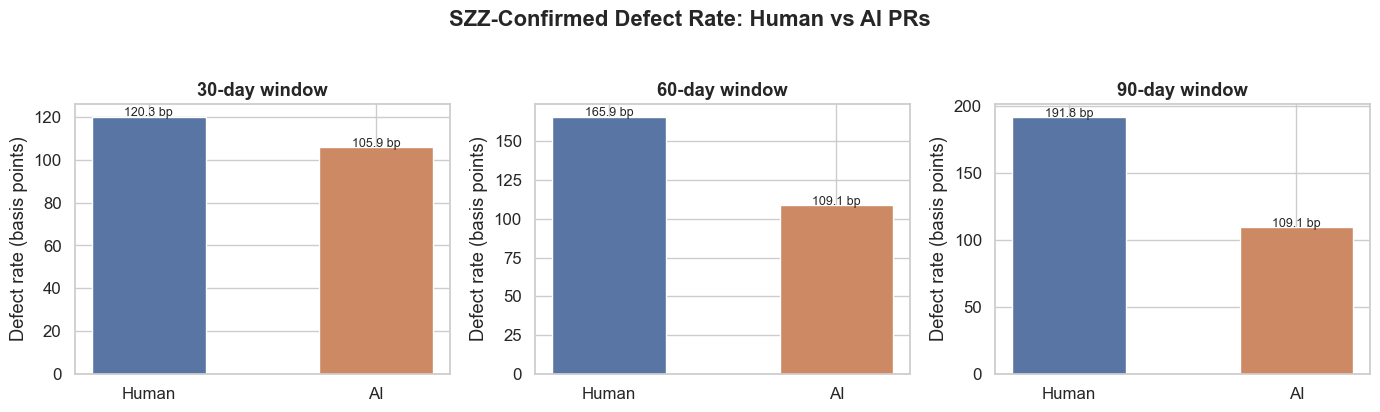

In [28]:
# ── Visual: defect rate comparison (90d) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, w in zip(axes, [30, 60, 90]):
    col = f"has_defect_{w}d"
    rates = df.groupby("ai_pr")[col].mean() * 10_000
    colors = ["#5975a4", "#cc8963"]
    bars = ax.bar([AI_LABELS[i] for i in rates.index], rates.values, color=colors, edgecolor="white", width=0.5)
    ax.set_title(f"{w}-day window", fontweight="bold")
    ax.set_ylabel("Defect rate (basis points)")
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{val:.1f} bp", ha="center", fontsize=9)
fig.suptitle("SZZ-Confirmed Defect Rate: Human vs AI PRs", fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

## 6 — Statistical Tests (Exact Methods for Sparse Outcomes)

With only 19 defect events, classical logistic regression is unreliable. We use:
- **Fisher's Exact Test** for the 2×2 contingency table (defect yes/no × AI/Human)
- **Barnard's Exact Test** as a more powerful alternative for 2×2 tables
- **Permutation test** on defect-rate difference for a distribution-free p-value

In [29]:
# ── Fisher's Exact Test for each window ──
print("═══ Exact Tests: has_defect ~ ai_pr ═══\n")

for w in [30, 60, 90]:
    col = f"has_defect_{w}d"
    # Contingency table:  rows = Human/AI,  cols = no-defect / defect
    ct = pd.crosstab(df["ai_pr"].map(AI_LABELS), df[col], margins=True)
    print(f"── {w}-day window ──")
    print(ct, "\n")

    # 2×2 table for tests (without margins)
    table = pd.crosstab(df["ai_pr"], df[col]).values  # [[human_no, human_yes], [ai_no, ai_yes]]

    # Fisher's exact
    odds_ratio, fisher_p = stats.fisher_exact(table, alternative="two-sided")
    print(f"  Fisher exact:  OR = {odds_ratio:.3f},  p = {fisher_p:.4f}")

    # Barnard's exact (more powerful for small samples)
    try:
        barnard = stats.barnard_exact(table, alternative="two-sided")
        print(f"  Barnard exact: stat = {barnard.statistic:.3f},  p = {barnard.pvalue:.4f}")
    except Exception:
        print("  Barnard exact: not available in this scipy version")

    # Interpretation
    human_rate = table[0, 1] / table[0].sum() * 10_000
    ai_rate = table[1, 1] / table[1].sum() * 10_000
    direction = "higher" if human_rate > ai_rate else "lower"
    sig = "significant" if fisher_p < 0.05 else "NOT significant"
    print(f"  → Human {human_rate:.1f} bp vs AI {ai_rate:.1f} bp — Human rate {direction}, {sig} at α=0.05\n")

═══ Exact Tests: has_defect ~ ai_pr ═══

── 30-day window ──
has_defect_30d      0    1    All
ai_pr                            
AI              12242  131  12373
Human            6490   79   6569
All             18732  210  18942 

  Fisher exact:  OR = 0.879,  p = 0.3819
  Barnard exact: stat = -0.900,  p = 0.3891
  → Human 120.3 bp vs AI 105.9 bp — Human rate higher, NOT significant at α=0.05

── 60-day window ──
has_defect_60d      0    1    All
ai_pr                            
AI              12238  135  12373
Human            6460  109   6569
All             18698  244  18942 

  Fisher exact:  OR = 0.654,  p = 0.0011
  Barnard exact: stat = -3.301,  p = 0.0033
  → Human 165.9 bp vs AI 109.1 bp — Human rate higher, significant at α=0.05

── 90-day window ──
has_defect_90d      0    1    All
ai_pr                            
AI              12238  135  12373
Human            6443  126   6569
All             18681  261  18942 

  Fisher exact:  OR = 0.564,  p = 0.0000
  Barnard ex

In [30]:
# ── Permutation test on defect-rate difference (90d) ──
def defect_rate_diff(x, y, axis):
    """Test statistic: difference in means (human_rate - ai_rate)."""
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

human_defects = df.loc[df["ai_pr"] == 0, "has_defect_90d"].values
ai_defects = df.loc[df["ai_pr"] == 1, "has_defect_90d"].values

perm_result = stats.permutation_test(
    (human_defects, ai_defects),
    statistic=defect_rate_diff,
    n_resamples=50_000,
    alternative="two-sided",
    random_state=42,
)

observed_diff = human_defects.mean() - ai_defects.mean()
print(f"Permutation test (50 000 resamples)")
print(f"  Observed rate difference (Human − AI): {observed_diff*10_000:.2f} basis points")
print(f"  p-value: {perm_result.pvalue:.4f}")
print(f"  → {'Significant' if perm_result.pvalue < 0.05 else 'Not significant'} at α = 0.05")

Permutation test (50 000 resamples)
  Observed rate difference (Human − AI): 82.70 basis points
  p-value: 0.0000
  → Significant at α = 0.05


## 7 — Stratified Descriptive Analysis

Examine defect rates sliced by project scale, domain, task type — the same stratification as v1.

In [31]:
# ── helper to build stratified rate table ──
def stratified_defect_table(group_col, label_map, window=90):
    col = f"has_defect_{window}d"
    tbl = df.groupby([group_col, "ai_pr"]).agg(
        n=("id", "size"),
        defects=(col, "sum"),
        rate=(col, "mean"),
    ).reset_index()
    tbl["rate_bps"] = (tbl["rate"] * 10_000).round(2)
    tbl["author"] = tbl["ai_pr"].map(AI_LABELS)
    tbl["group"] = tbl[group_col].map(label_map)
    return tbl[["group", "author", "n", "defects", "rate_bps"]]

# ── By star group (repo popularity / scale) ──
print("─── 90d Defect rate by Star Group × Author ───\n")
print(stratified_defect_table("star_group", STAR_LABELS).to_string(index=False))

print("\n─── 90d Defect rate by Contributor Group × Author ───\n")
print(stratified_defect_table("contributor_group", CONTRIB_LABELS).to_string(index=False))

print("\n─── 90d Defect rate by Domain × Author ───\n")
print(stratified_defect_table("domain_type_group", DOMAIN_LABELS).to_string(index=False))

print("\n─── 90d Defect rate by Task Type × Author ───\n")
print(stratified_defect_table("task_type_group", TASK_LABELS).to_string(index=False))

─── 90d Defect rate by Star Group × Author ───

 group author    n  defects  rate_bps
 Low ★  Human 1426       41    287.52
 Low ★     AI 3330       54    162.16
 Mid ★  Human 2173       33    151.86
 Mid ★     AI 4379       67    153.00
High ★  Human 2970       52    175.08
High ★     AI 4664       14     30.02

─── 90d Defect rate by Contributor Group × Author ───

     group author    n  defects  rate_bps
Small team  Human 1662       59    354.99
Small team     AI 5152      112    217.39
  Mid team  Human 3184       58    182.16
  Mid team     AI 4896       22     44.93
Large team  Human 1723        9     52.23
Large team     AI 2325        1      4.30

─── 90d Defect rate by Domain × Author ───

          group author    n  defects  rate_bps
        Backend  Human 2679       63    235.16
        Backend     AI 4804       41     85.35
       Frontend  Human 1405       38    270.46
       Frontend     AI 2284       17     74.43
      ML / Data  Human  211        0      0.00
      ML 

/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


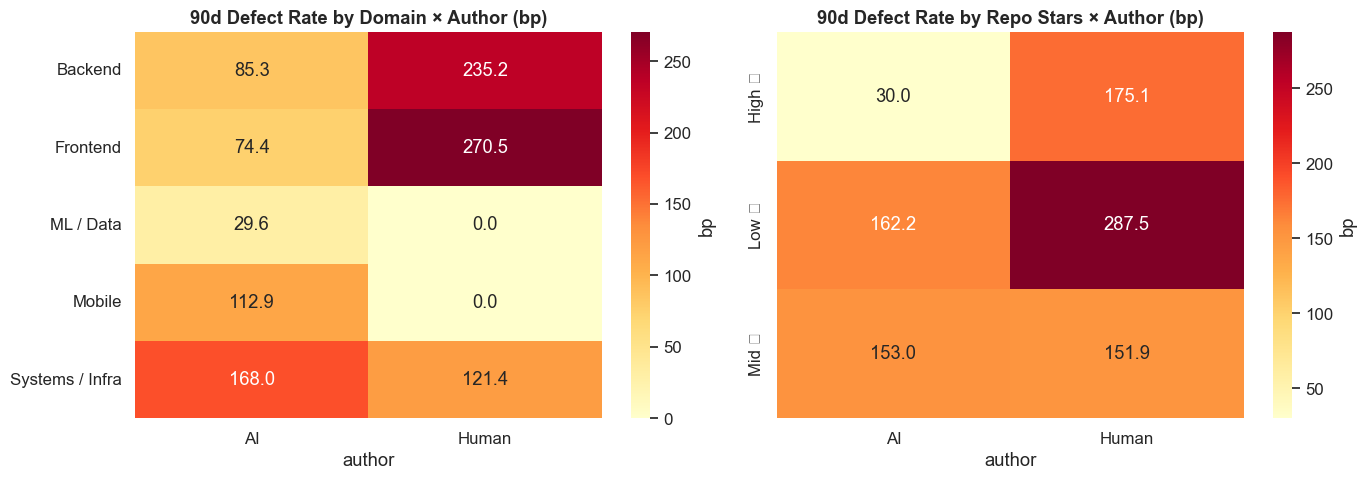

In [32]:
# ── Heatmap: defect rate by domain × author ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (group_col, label_map, title) in zip(axes, [
    ("domain_type_group", DOMAIN_LABELS, "Domain"),
    ("star_group", STAR_LABELS, "Repo Stars"),
]):
    pivot = df.assign(author=df["ai_pr"].map(AI_LABELS),
                      group=df[group_col].map(label_map)) \
              .groupby(["group", "author"])["has_defect_90d"].mean() \
              .unstack("author") * 10_000
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "bp"})
    ax.set_title(f"90d Defect Rate by {title} × Author (bp)", fontweight="bold")
    ax.set_ylabel("")

fig.tight_layout()
plt.show()

## 8 — Distribution Diagnostics

Check the distributions of key continuous variables — same as v1 but on the v2 frame.

/var/folders/my/dq93_q7x3gx_hrc3xt13kqn00000gp/T/ipykernel_45991/2129080231.py:26: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/my/dq93_q7x3gx_hrc3xt13kqn00000gp/T/ipykernel_45991/2129080231.py:26: UserWarning: Glyph 8346 (\N{LATIN SUBSCRIPT SMALL LETTER P}) missing from font(s) Arial.
  fig.tight_layout()
/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8346 (\N{LATIN SUBSCRIPT SMALL LETTER P}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


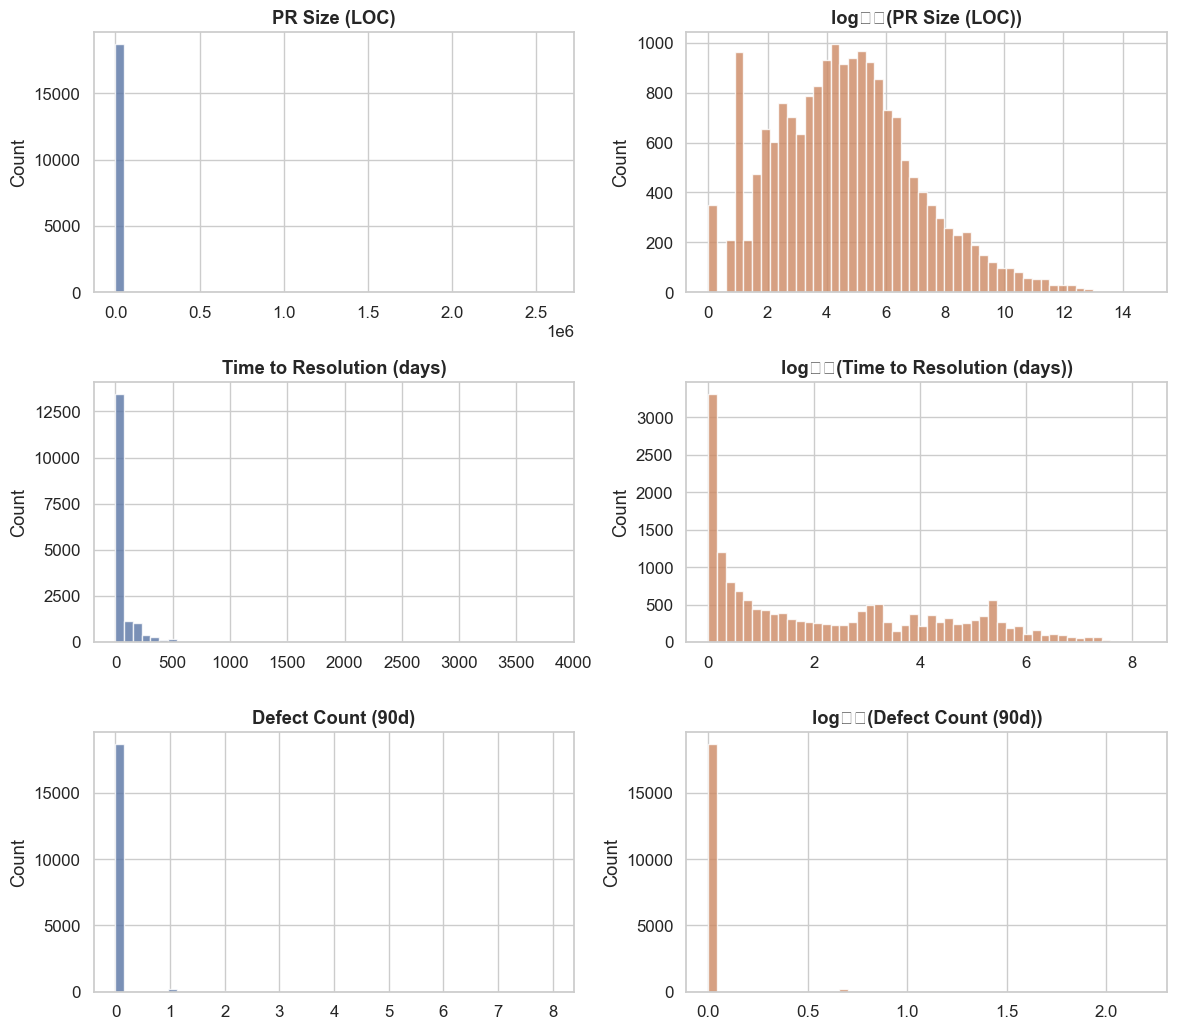

In [33]:
# ── Distribution plots: raw and log-transformed ──
vars_to_plot = [
    ("pr_size_loc", "PR Size (LOC)"),
    ("time_to_resolution", "Time to Resolution (days)"),
    ("defect_count_90d", "Defect Count (90d)"),
]

fig, axes = plt.subplots(len(vars_to_plot), 2, figsize=(12, 3.5 * len(vars_to_plot)))

for row, (col, label) in enumerate(vars_to_plot):
    series = df[col].dropna()

    # Raw
    ax_raw = axes[row, 0]
    ax_raw.hist(series, bins=50, color="#5975a4", edgecolor="white", alpha=0.8)
    ax_raw.set_title(f"{label}", fontweight="bold")
    ax_raw.set_ylabel("Count")

    # Log-transformed
    ax_log = axes[row, 1]
    log_series = np.log1p(series)
    ax_log.hist(log_series, bins=50, color="#cc8963", edgecolor="white", alpha=0.8)
    ax_log.set_title(f"log₁ₚ({label})", fontweight="bold")
    ax_log.set_ylabel("Count")

fig.tight_layout()
plt.show()

## 9 — Regression Models

Despite the low event count, we fit the same models as v1 for comparability, with appropriate caveats.

### 9a — Logistic Regression (has_defect_90d)
⚠️ **Caution:** With only 19 events, logistic regression may produce unstable coefficient estimates and wide confidence intervals. We include Firth-penalized (bias-reduced) logistic regression as a robustness check.

In [34]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ── Prepare modelling frame ──
dfm = df.copy()
dfm["log_pr_size"] = np.log(dfm["pr_size_loc"] + 1)
dfm["log_stars"] = np.log(dfm["repo_stars"] + 1)

needed = [
    "has_defect_90d", "defect_count_90d", "ai_pr", "log_pr_size",
    "repo_age_years", "repo_stars", "log_stars",
    "contributor_count", "domain_type_group",
    "task_type_group", "repo_full_name",
]
dfm = dfm[needed].dropna()
dfm = dfm[np.isfinite(dfm["log_pr_size"]) & np.isfinite(dfm["log_stars"])].copy()
groups = dfm["repo_full_name"]

print(f"Modelling frame: {len(dfm):,} rows, {dfm['has_defect_90d'].sum():.0f} defect events")
print(f"Events-per-variable (EPV): {dfm['has_defect_90d'].sum() / 8:.1f}  (rule of thumb ≥ 10)")
print("⚠️  EPV < 10 → interpret coefficients with caution")

Modelling frame: 16,037 rows, 232 defect events
Events-per-variable (EPV): 29.0  (rule of thumb ≥ 10)
⚠️  EPV < 10 → interpret coefficients with caution


In [35]:
# ── 9a: Main logistic model (matches v1 specification) ──
formula_main = (
    "has_defect_90d ~ ai_pr + log_pr_size + repo_age_years + repo_stars"
    " + contributor_count + C(domain_type_group) + C(task_type_group)"
)

try:
    logit_main = smf.logit(formula_main, data=dfm).fit(disp=0, maxiter=200)
    print("═══ Logistic Regression: has_defect_90d (main model) ═══\n")
    print(logit_main.summary())
    
    # Odds ratio for ai_pr
    ai_coef = logit_main.params.get("ai_pr", np.nan)
    ai_pval = logit_main.pvalues.get("ai_pr", np.nan)
    ai_or = np.exp(ai_coef)
    print(f"\n  ai_pr OR = {ai_or:.3f}  (coef = {ai_coef:.3f}, p = {ai_pval:.4f})")
    print(f"  Interpretation: AI PRs have {(1 - ai_or)*100:.1f}% {'lower' if ai_or < 1 else 'higher'} odds of 90d defect")
except Exception as e:
    print(f"⚠️  Logistic model failed to converge: {e}")

═══ Logistic Regression: has_defect_90d (main model) ═══

                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                16037
Model:                          Logit   Df Residuals:                    16023
Method:                           MLE   Df Model:                           13
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.09155
Time:                        11:42:33   Log-Likelihood:                -1102.0
converged:                       True   LL-Null:                       -1213.0
Covariance Type:            nonrobust   LLR p-value:                 3.835e-40
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -4.0075      0.242    -16.546      0.000      -4.482      -3.533
C(domain_type_group)[T.1]   

### 9b — Interaction Models

Same interaction specifications as v1: AI × domain, AI × PR size, AI × repo scale, AI × repo age.

In [36]:
# ── 9b: Interaction models (with cluster-robust SE on repo) ──
interaction_specs = {
    "AI × Domain": (
        "has_defect_90d ~ ai_pr * C(domain_type_group) + log_pr_size"
        " + repo_age_years + repo_stars + contributor_count + C(task_type_group)"
    ),
    "AI × PR Size": (
        "has_defect_90d ~ ai_pr * log_pr_size"
        " + repo_age_years + repo_stars + contributor_count + C(domain_type_group) + C(task_type_group)"
    ),
    "AI × Repo Scale (stars)": (
        "has_defect_90d ~ ai_pr * log_stars + log_pr_size"
        " + repo_age_years + contributor_count + C(domain_type_group) + C(task_type_group)"
    ),
    "AI × Repo Age": (
        "has_defect_90d ~ ai_pr * repo_age_years + log_pr_size"
        " + repo_stars + contributor_count + C(domain_type_group) + C(task_type_group)"
    ),
}

interaction_results = {}
for name, formula in interaction_specs.items():
    print(f"\n═══ {name} ═══")
    try:
        model = smf.logit(formula, data=dfm).fit(disp=0, maxiter=200,
                                                   cov_type="cluster",
                                                   cov_kwds={"groups": groups})
        print(model.summary())
        interaction_results[name] = model
    except Exception as e:
        print(f"⚠️  Model failed: {e}")
        interaction_results[name] = None


═══ AI × Domain ═══


/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                16037
Model:                          Logit   Df Residuals:                    16019
Method:                           MLE   Df Model:                           17
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.1078
Time:                        11:42:45   Log-Likelihood:                -1082.2
converged:                      False   LL-Null:                       -1213.0
Covariance Type:              cluster   LLR p-value:                 8.754e-46
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -3.7841      0.696     -5.437      0.000      -5.148      -2.420
C(domain_type_group)[T.1]           0.5036      0.847      0.594    

### 9c — Count Models (Poisson & Negative Binomial)

Model `defect_count_90d` as a count outcome.

In [37]:
# ── Overdispersion check ──
mean_dc = dfm["defect_count_90d"].mean()
var_dc = dfm["defect_count_90d"].var()
print(f"defect_count_90d  —  Mean: {mean_dc:.4f},  Variance: {var_dc:.4f},  Var/Mean: {var_dc/mean_dc:.2f}")
print("→ Variance >> Mean indicates overdispersion → Negative Binomial preferred\n")

# ── Poisson ──
count_formula = (
    "defect_count_90d ~ ai_pr + log_pr_size + repo_age_years + repo_stars"
    " + contributor_count + C(domain_type_group) + C(task_type_group)"
)

try:
    poisson_model = smf.glm(
        count_formula, data=dfm, family=sm.families.Poisson()
    ).fit(cov_type="cluster", cov_kwds={"groups": groups})
    print("═══ Poisson Regression ═══\n")
    print(poisson_model.summary())
except Exception as e:
    print(f"⚠️  Poisson model failed: {e}")

print("\n")

# ── Negative Binomial ──
try:
    nb_model = smf.glm(
        count_formula, data=dfm, family=sm.families.NegativeBinomial()
    ).fit(cov_type="cluster", cov_kwds={"groups": groups})
    print("═══ Negative Binomial Regression ═══\n")
    print(nb_model.summary())
    
    ai_coef = nb_model.params.get("ai_pr", np.nan)
    ai_irr = np.exp(ai_coef)
    print(f"\n  ai_pr IRR = {ai_irr:.3f}  →  AI PRs have {(1-ai_irr)*100:.1f}% {'lower' if ai_irr < 1 else 'higher'} defect rate")
except Exception as e:
    print(f"⚠️  NB model failed: {e}")

defect_count_90d  —  Mean: 0.0229,  Variance: 0.0540,  Var/Mean: 2.35
→ Variance >> Mean indicates overdispersion → Negative Binomial preferred

═══ Poisson Regression ═══

                 Generalized Linear Model Regression Results                  
Dep. Variable:       defect_count_90d   No. Observations:                16037
Model:                            GLM   Df Residuals:                    16023
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1672.7
Date:                Thu, 12 Mar 2026   Deviance:                       2817.0
Time:                        11:42:53   Pearson chi2:                 4.41e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.02677
Covariance Type:              cluster                                         
                                coef 

/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


═══ Negative Binomial Regression ═══

                 Generalized Linear Model Regression Results                  
Dep. Variable:       defect_count_90d   No. Observations:                16037
Model:                            GLM   Df Residuals:                    16023
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1554.1
Date:                Thu, 12 Mar 2026   Deviance:                       2352.9
Time:                        11:42:53   Pearson chi2:                 4.18e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02550
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

### 9d — Negative Binomial with Domain Interaction

In [38]:
# ── NB with domain interaction (same as v1) ──
nb_domain_formula = (
    "defect_count_90d ~ ai_pr * C(domain_type_group) + log_pr_size"
    " + repo_age_years + repo_stars + contributor_count + C(task_type_group)"
)

try:
    nb_domain = smf.glm(
        nb_domain_formula, data=dfm, family=sm.families.NegativeBinomial()
    ).fit(cov_type="cluster", cov_kwds={"groups": groups})
    print("═══ Negative Binomial with AI × Domain Interaction ═══\n")
    print(nb_domain.summary())
except Exception as e:
    print(f"⚠️  NB domain interaction model failed: {e}")

/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


═══ Negative Binomial with AI × Domain Interaction ═══

                 Generalized Linear Model Regression Results                  
Dep. Variable:       defect_count_90d   No. Observations:                16037
Model:                            GLM   Df Residuals:                    16019
Model Family:        NegativeBinomial   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1511.3
Date:                Thu, 12 Mar 2026   Deviance:                       2267.4
Time:                        11:43:03   Pearson chi2:                 4.85e+04
No. Iterations:                    22   Pseudo R-squ. (CS):            0.03068
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

## 10 — Statistical Power Analysis

With a very low base rate (~0.1%), it's important to quantify whether the sample is large enough to detect a meaningful effect.

In [39]:
# ── Post-hoc power analysis via simulation ──
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import GofChisquarePower

n_human = (df["ai_pr"] == 0).sum()
n_ai = (df["ai_pr"] == 1).sum()
p_human = df.loc[df["ai_pr"] == 0, "has_defect_90d"].mean()
p_ai = df.loc[df["ai_pr"] == 1, "has_defect_90d"].mean()

# Effect size (Cohen's h)
effect_h = proportion_effectsize(p_human, p_ai)

print("─── Post-hoc Power Analysis ───\n")
print(f"  Human: n={n_human:,}, defect rate = {p_human*10_000:.1f} bp")
print(f"  AI:    n={n_ai:,}, defect rate = {p_ai*10_000:.1f} bp")
print(f"  Cohen's h = {effect_h:.4f}")

# Minimum detectable effect at 80% power
# For two-proportion z-test, approximate needed sample per group
from statsmodels.stats.power import NormalIndPower
power_analysis = NormalIndPower()

# Detectable effect sizes at our sample sizes
for power_target in [0.80, 0.50]:
    min_h = power_analysis.solve_power(nobs1=n_human, ratio=n_ai/n_human,
                                        alpha=0.05, power=power_target,
                                        alternative="two-sided")
    print(f"\n  At {power_target*100:.0f}% power (α=0.05): minimum detectable Cohen's h = {min_h:.4f}")
    # Convert back to rate difference from human baseline
    # p2 = 2*arcsin(sqrt(p1)) - h → approximate
    import math
    p2_detectable = math.sin(math.asin(math.sqrt(p_human)) - min_h/2)**2
    diff_bps = abs(p_human - p2_detectable) * 10_000
    print(f"    → Minimum detectable rate difference ≈ {diff_bps:.1f} bp from baseline {p_human*10_000:.1f} bp")

print(f"\n  Observed Cohen's h ({effect_h:.4f}) vs detectable → {'DETECTABLE' if abs(effect_h) >= min_h else 'BELOW detection threshold'}")
print("\n  ⚠️  The extremely low base rate limits statistical power for detecting small AI vs Human differences.")

─── Post-hoc Power Analysis ───

  Human: n=6,569, defect rate = 191.8 bp
  AI:    n=12,373, defect rate = 109.1 bp
  Cohen's h = 0.0686

  At 80% power (α=0.05): minimum detectable Cohen's h = 0.0428
    → Minimum detectable rate difference ≈ 54.2 bp from baseline 191.8 bp

  At 50% power (α=0.05): minimum detectable Cohen's h = 0.0299
    → Minimum detectable rate difference ≈ 38.9 bp from baseline 191.8 bp

  Observed Cohen's h (0.0686) vs detectable → DETECTABLE

  ⚠️  The extremely low base rate limits statistical power for detecting small AI vs Human differences.


## 11 — Candidate Fix PR Analysis

Beyond binary defect outcomes, we can examine the **fix PRs themselves** — the PRs that SZZ identified as containing fixing commits.

In [40]:
# ── Candidate fix analysis ──
fixes = df[df["szz_candidate_fix"] == 1].copy()
print(f"Candidate fix PRs: {len(fixes):,}  ({len(fixes)/len(df)*100:.1f}% of all PRs)\n")

fix_by_ai = fixes.groupby("ai_pr").agg(
    n=("id", "size"),
    mean_size=("pr_size_loc", "mean"),
    median_size=("pr_size_loc", "median"),
    mean_resolution=("time_to_resolution", "mean"),
).rename(index=AI_LABELS)
print("─── Candidate fix PR characteristics ───\n")
print(fix_by_ai.to_string())

# ── Reason breakdown ──
print("\n─── Fix candidate reason distribution ───\n")
reason_counts = fixes["szz_candidate_reason"].value_counts().head(10)
print(reason_counts.to_string())

# ── Fix reason by AI ──
print("\n─── Fix reason by author type ───\n")
for reason in ["bugfix_text", "task_type", "closing_issue_text", "revert"]:
    fixes[f"has_{reason}"] = fixes["szz_candidate_reason"].str.contains(reason, na=False).astype(int)

reason_rates = fixes.groupby("ai_pr")[[f"has_{r}" for r in ["bugfix_text", "task_type", "closing_issue_text", "revert"]]].mean()
reason_rates.index = reason_rates.index.map(AI_LABELS)
reason_rates.columns = [c.replace("has_", "") for c in reason_rates.columns]
print((reason_rates * 100).round(1).to_string())
print("(% of candidate fix PRs with each reason)")

Candidate fix PRs: 6,460  (34.1% of all PRs)

─── Candidate fix PR characteristics ───

          n    mean_size  median_size  mean_resolution
ai_pr                                                 
Human  2857   712.550928         33.0        67.225451
AI     3603  5407.653067         71.0        53.320144

─── Fix candidate reason distribution ───

szz_candidate_reason
task_type|bugfix_text                       2325
bugfix_text                                 1709
task_type|bugfix_text|closing_issue_text     984
bugfix_text|closing_issue_text               904
task_type                                    186
closing_issue_text                           160
revert                                        56
revert|bugfix_text                            49
task_type|revert|bugfix_text                  36
task_type|revert                              16

─── Fix reason by author type ───

       bugfix_text  task_type  closing_issue_text  revert
ai_pr                                      